In [ ]:


import os, copy
from pathlib import Path
from datetime import datetime

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import timm
import pandas as pd
from tqdm import tqdm

DATA_ROOT = "./data/eurosat"
OUTPUT_DIR = "./outputs_eurosat"
BATCH_SIZE = 64
IMG_SIZE = 224
NUM_WORKERS = 2
EPOCHS = 5         
LR = 1e-3
WEIGHT_DECAY = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PRETRAINED = True

MODEL_NAMES = [
    "resnet50",
    "efficientnet_b0",
    "vit_small_patch16_224",
]

def get_eurosat_dataset(root, img_size, train=True, download=True):
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip() if train else transforms.Lambda(lambda x: x),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    try:
        from torchvision.datasets import EuroSAT
        ds = EuroSAT(root=root, download=download, transform=transform)
        print("Loaded EuroSAT from torchvision.datasets.")
        return ds
    except Exception as e:
        print("Falling back to ImageFolder:", e)
        ds = datasets.ImageFolder(root=str(Path(root)), transform=transform)
        return ds

def create_dataloaders(root, img_size, batch_size, num_workers):
    ds_full = get_eurosat_dataset(root, img_size, train=True, download=True)
    n = len(ds_full)
    val_size = int(0.2 * n)
    train_size = n - val_size
    train_ds, val_ds = torch.utils.data.random_split(ds_full, [train_size, val_size])
    val_ds.dataset.transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers),
        train_size, val_size, ds_full
    )

def build_model(name, num_classes):
    model = timm.create_model(name, pretrained=PRETRAINED, num_classes=num_classes)
    return model.to(DEVICE)

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x,y in tqdm(loader, desc="Train", leave=False):
        x,y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out,y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()*x.size(0)
        correct += (out.argmax(1)==y).sum().item()
        total += x.size(0)
    return total_loss/total, 100*correct/total

def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x,y in tqdm(loader, desc="Val", leave=False):
            x,y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss = criterion(out,y)
            total_loss += loss.item()*x.size(0)
            correct += (out.argmax(1)==y).sum().item()
            total += x.size(0)
    return total_loss/total, 100*correct/total

# ----------------------------
# Main loop
# ----------------------------
def run_experiments(model_names, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    train_loader, val_loader, _, _, ds_full = create_dataloaders(DATA_ROOT, IMG_SIZE, BATCH_SIZE, NUM_WORKERS)
    num_classes = len(ds_full.classes)
    results = []

    for name in model_names:
        print("="*60)
        print(f"Training {name}")
        model = build_model(name, num_classes)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

        best_acc = 0
        for epoch in range(1, EPOCHS+1):
            print(f"Epoch {epoch}/{EPOCHS}")
            tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
            val_loss, val_acc = validate(model, val_loader, criterion)
            print(f"Train acc {tr_acc:.2f}%, Val acc {val_acc:.2f}%")

            if val_acc > best_acc:
                best_acc = val_acc
                torch.save(model.state_dict(), Path(output_dir)/f"{name}_best.pth")

        results.append({"model": name, "best_val_acc": best_acc})

    df = pd.DataFrame(results)
    df.to_csv(Path(output_dir)/"summary.csv", index=False)
    print("\nSummary:\n", df)

# ----------------------------
# Run
# ----------------------------
run_experiments(MODEL_NAMES, OUTPUT_DIR)


100%|██████████| 94.3M/94.3M [00:25<00:00, 3.71MB/s]


Loaded EuroSAT from torchvision.datasets.
Training resnet50
Epoch 1/5


Train acc 90.81%, Val acc 96.67%
Epoch 2/5


Train acc 96.81%, Val acc 97.09%
Epoch 3/5


Train acc 98.24%, Val acc 96.19%
Epoch 4/5


...

Train acc 65.84%, Val acc 83.59%
Epoch 2/5


Train acc 85.00%, Val acc 85.52%
Epoch 3/5


Train acc 88.60%, Val acc 90.13%
Epoch 4/5


Train acc 89.89%, Val acc 89.33%
Epoch 5/5


Train acc 91.16%, Val acc 90.54%

Summary:
                    model  best_val_acc
0               resnet50     98.185185
1        efficientnet_b0     97.425926
2  vit_small_patch16_224     90.537037


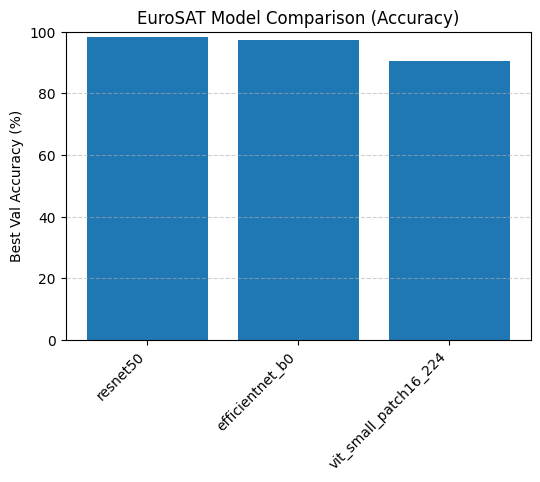

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

summary_path = "./outputs_eurosat/summary.csv"
df = pd.read_csv(summary_path)

# Bar plot of best validation accuracy
plt.figure(figsize=(6,4))
plt.bar(df["model"], df["best_val_acc"])
plt.title("EuroSAT Model Comparison (Accuracy)")
plt.ylabel("Best Val Accuracy (%)")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()
